# Regression Analyses (work in progress--more code and much more documentation to come)

In [103]:
df_survey_results

,student_id,starting_year,season,...,college,level,level_for_sorting
0,2020-1,2023,Fall,...,STC,Fr,0
1,2020-2,2023,Fall,...,STM,Fr,0
2,2020-3,2023,Fall,...,STC,Fr,0
3,2020-4,2023,Fall,...,STC,Fr,0
...,...,...,...,...,...,...,...
46690,2023-1318,2023,Winter,...,STB,Se,3
46691,2020-2,2023,Winter,...,STM,Fr,0
46692,2023-615,2023,Winter,...,STM,Se,3
46693,2020-1015,2023,Winter,...,STC,Fr,0


In [57]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
e = create_engine('sqlite:///../Appendix/nvcu_db.db')
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px

import sys
sys.path.insert(1, '../Appendix')
from helper_funcs import config_notebook, wadi
display_type = config_notebook(display_max_columns = 7,
                              display_max_rows = 8)
df_survey_results = pd.read_csv(
    '../Data_Prep/2023_survey_results.csv')


In [108]:
df_demographics = pd.read_sql(
    "select student_id, gender, college, level from \
curr_enrollment", con = e)
df_demographics

,student_id,gender,college,level
0,2020-1,F,STC,Fr
1,2020-2,F,STM,Fr
2,2020-3,F,STC,Fr
3,2020-4,F,STC,Fr
...,...,...,...,...
16380,2023-5440,M,STM,Se
16381,2023-5441,M,STL,Se
16382,2023-5442,M,STB,Se
16383,2023-5443,M,STM,Se


In [111]:
df_survey_results = pd.read_sql("select * from survey_results", 
                                con = e)
df_survey_results

,student_id,starting_year,season,score
0,2020-1,2023,Fall,88
1,2020-2,2023,Fall,37
2,2020-3,2023,Fall,54
3,2020-4,2023,Fall,56
...,...,...,...,...
32764,2023-5440,2023,Spring,100
32765,2023-5441,2023,Spring,89
32766,2023-5442,2023,Spring,64
32767,2023-5443,2023,Spring,77


In [114]:
df_results_and_demographics = df_survey_results.merge(
    df_demographics, on = 'student_id', how = 'inner')
df_results_and_demographics

,student_id,starting_year,season,score,gender,college,level
0,2020-1,2023,Fall,88,F,STC,Fr
1,2020-2,2023,Fall,37,F,STM,Fr
2,2020-3,2023,Fall,54,F,STC,Fr
3,2020-4,2023,Fall,56,F,STC,Fr
...,...,...,...,...,...,...,...
32764,2023-5440,2023,Spring,100,M,STM,Se
32765,2023-5441,2023,Spring,89,M,STL,Se
32766,2023-5442,2023,Spring,64,M,STB,Se
32767,2023-5443,2023,Spring,77,M,STM,Se


Creating a pivot table for our regression:

In order to determine the impact of college and level on students' fall and spring scores, we'll need to place those scores side by side. We can accomplish this by calling `df.pivot()` and passing 'season' to its `columns` argument.

In [117]:
df_regression = df_results_and_demographics.pivot(
    index = ['student_id', 'gender', 'college', 'level'],
                        columns = 'season', 
                        values = 'score').reset_index()

df_regression.query("Fall <= 72", inplace = True) # Survey scores cannot
# be above 100; thus, for very high fall scores, the average fall-spring
# growth got constrained (as scores had less room to climb than did 
# lower scores). In order to prevent this phenomenon from influencing
# our regression, I decided to limit the dataset to lower fall scores.
# There are undoubtedly better ways of handling this ceiling effect
# for real-world applications, but this approach will suffice for
# a simulated example like this one.

df_regression['const'] = 1 # This value will prove useful
# within regression analyses that don't use Statsmodels' formula api 
# (which adds the constant on its own; 
# see https://www.statsmodels.org/stable/examples/notebooks/generated/formulas.html).
# Statsmodels does have an 
# add_constant() function that can accomplish this step for us,
# but it's even simpler to just add it within Pandas.
df_regression

season,student_id,gender,college,level,Fall,Spring,const
1,2020-10,F,STB,Fr,69,73,1
2,2020-100,F,STL,Fr,68,88,1
3,2020-1000,F,STM,Fr,58,65,1
5,2020-1002,F,STM,Fr,62,59,1
...,...,...,...,...,...,...,...
16377,2023-993,F,STL,Se,55,72,1
16380,2023-996,F,STM,Se,62,69,1
16381,2023-997,F,STB,Se,47,42,1
16383,2023-999,F,STC,Se,64,65,1


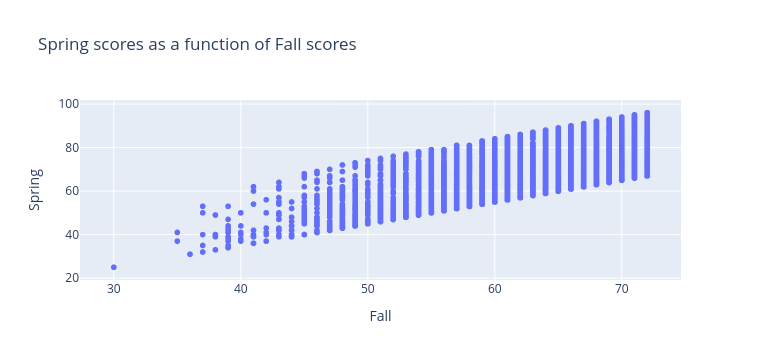

In [118]:
fig_fall_spring_comparison = px.scatter(
    df_regression, x = 'Fall', y = 'Spring',
title = 'Spring scores as a function of Fall scores')
fig_fall_spring_comparison

The following cell defines a function that, given a list of index values, can create a pivot table showing changes in fall/spring scores for each combination of those values. It is designed to work specifically with `df_regression` but could be modified to accommodate other DataFrames as well.

In [119]:
def change_pivot(index_list):
    '''This function compares fall and spring scores within df_regression
    for the index values specified in index_list.'''
    df_change = df_regression.pivot_table(
    index = index_list, values = ['Fall', 'Spring'], 
                          aggfunc = 'mean').reset_index()
    df_change['Fall to Spring Change'] = (
    df_change['Spring'] - 
    df_change['Fall'])
    df_change.sort_values('Fall to Spring Change', ascending = False,
                         inplace = True)
    return df_change

In [120]:
df_change_by_college = change_pivot(['gender'])
df_change_by_college

season,gender,Fall,Spring,Fall to Spring Change
0,F,63.416717,65.953877,2.537160
1,M,63.381274,65.817695,2.436421


In [121]:
df_change_by_college = change_pivot(['college'])
df_change_by_college

season,college,Fall,Spring,Fall to Spring Change
2,STL,63.370435,70.769130,7.398696
3,STM,63.397545,70.497784,7.100239
0,STB,63.452164,60.768956,-2.683208
1,STC,63.370009,60.617569,-2.752440


In [122]:
df_change_by_level = change_pivot(
    index_list = ['level'])
df_change_by_level

season,level,Fall,Spring,Fall to Spring Change
2,Se,63.371162,68.809151,5.437989
0,Fr,63.378863,67.428714,4.049850
1,Ju,63.480210,63.353796,-0.126414
3,So,63.367393,62.914623,-0.452770


In [123]:
df_change_by_college_and_level = change_pivot(
    index_list = ['college', 'level'])
df_change_by_college_and_level

season,college,level,Fall,Spring,Fall to Spring Change
10,STL,Se,63.289700,73.261803,9.972103
12,STM,Fr,63.844262,73.540984,9.696721
14,STM,Se,63.084646,72.437008,9.352362
8,STL,Fr,63.226115,72.321656,9.095541
...,...,...,...,...,...
7,STC,So,63.292308,58.292308,-5.000000
5,STC,Ju,63.328273,58.328273,-5.000000
1,STB,Ju,63.713166,58.713166,-5.000000
3,STB,So,63.216931,58.216931,-5.000000


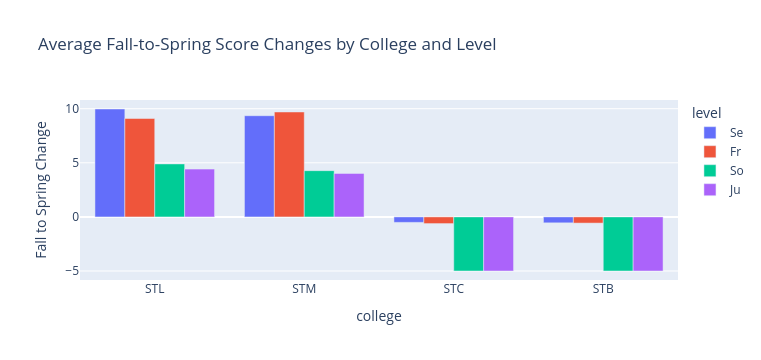

In [124]:
px.bar(df_change_by_college_and_level, x = 'college',
       y = 'Fall to Spring Change', color = 'level',
      barmode = 'group',
      title = 'Average Fall-to-Spring Score Changes by College and Level')

### Creating a linear regression using a formula approach:

(The documentation at https://www.statsmodels.org/stable/examples/notebooks/generated/formulas.html proved very helpful in writing this section.)

In [126]:
lr_model = smf.ols(formula = "Spring ~ Fall + gender", 
                   data = df_regression) 
lr_results = lr_model.fit()
lr_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Spring   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     3306.
Date:                Thu, 30 Jan 2025   Prob (F-statistic):               0.00
Time:                        23:51:22   Log-Likelihood:                -34830.
No. Observations:               10006   AIC:                         6.967e+04
Df Residuals:                   10003   BIC:                         6.969e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       4.0892      0.769      5.317      0.000       2.582       5.597
gender[T.M]    -0.1016      0.157     -0.646      0.518      -0.410       0.207
Fall            0.9755      0.012     81.307      0.000       0.952       0.999
==============================================================================
Omnibus:                     1176.057   Durbin-Watson:                   1.802
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1648.491
Skew:                           0.994   Prob(JB):                         0.00
Kurtosis:                       3.047   Cond. No.                         624.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [125]:
lr_model = smf.ols(formula = "Spring ~ Fall", 
                   data = df_regression) 
lr_results = lr_model.fit()
lr_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Spring   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     6612.
Date:                Thu, 30 Jan 2025   Prob (F-statistic):               0.00
Time:                        23:51:11   Log-Likelihood:                -34830.
No. Observations:               10006   AIC:                         6.966e+04
Df Residuals:                   10004   BIC:                         6.968e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0367      0.765      5.279      0.000       2.538       5.536
Fall           0.9755      0.012     81.311      0.000       0.952       0.999
==============================================================================
Omnibus:                     1175.930   Durbin-Watson:                   1.802
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1648.269
Skew:                           0.994   Prob(JB):                         0.00
Kurtosis:                       3.047   Cond. No.                         620.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [102]:
lr_model = smf.ols(formula = "Spring ~ Fall + level", 
                   data = df_regression) 
lr_results = lr_model.fit()
lr_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Spring   R-squared:                       0.466
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     2180.
Date:                Thu, 30 Jan 2025   Prob (F-statistic):               0.00
Time:                        23:44:36   Log-Likelihood:                -34231.
No. Observations:               10006   AIC:                         6.847e+04
Df Residuals:                   10001   BIC:                         6.851e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       5.5027      0.735      7.485      0.000       4.062       6.944
level[T.Ju]    -4.1739      0.222    -18.760      0.000      -4.610      -3.738
level[T.Se]     1.3880      0.209      6.627      0.000       0.977       1.798
level[T.So]    -4.5029      0.229    -19.697      0.000      -4.951      -4.055
Fall            0.9771      0.011     86.445      0.000       0.955       0.999
==============================================================================
Omnibus:                     1040.728   Durbin-Watson:                   2.030
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1361.246
Skew:                           0.892   Prob(JB):                    2.57e-296
Kurtosis:                       2.719   Cond. No.                         636.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [101]:
lr_model = smf.ols(formula = "Spring ~ Fall + college", 
                   data = df_regression) 
lr_results = lr_model.fit()
lr_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Spring   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     4416.
Date:                Thu, 30 Jan 2025   Prob (F-statistic):               0.00
Time:                        23:44:23   Log-Likelihood:                -32278.
No. Observations:               10006   AIC:                         6.457e+04
Df Residuals:                   10001   BIC:                         6.460e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.2339      0.602     -2.049      0.041      -2.415      -0.053
college[T.STC]    -0.0711      0.177     -0.403      0.687      -0.417       0.275
college[T.STL]    10.0800      0.176     57.362      0.000       9.736      10.424
college[T.STM]     9.7822      0.166     59.101      0.000       9.458      10.107
Fall               0.9772      0.009    105.092      0.000       0.959       0.995
==============================================================================
Omnibus:                      316.395   Durbin-Watson:                   1.697
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              350.966
Skew:                           0.430   Prob(JB):                     6.15e-77
Kurtosis:                       3.318   Cond. No.                         632.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [129]:
lr_model = smf.ols(formula = "Spring ~ Fall + college + level", 
                   data = df_regression) 
lr_results = lr_model.fit()
params = lr_results.params # We'll use these in an upcoming demonstration
lr_results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Spring   R-squared:                       0.696
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     3267.
Date:                Thu, 30 Jan 2025   Prob (F-statistic):               0.00
Time:                        23:54:37   Log-Likelihood:                -31414.
No. Observations:               10006   AIC:                         6.284e+04
Df Residuals:                    9998   BIC:                         6.290e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.9093      0.564      1.613      0.107      -0.196       2.015
college[T.STC]     0.0055      0.163      0.034      0.973      -0.313       0.324
college[T.STL]     9.9777      0.162     61.720      0.000       9.661      10.295
college[T.STM]     9.6234      0.152     63.352      0.000       9.326       9.921
level[T.Ju]       -4.8684      0.169    -28.885      0.000      -5.199      -4.538
level[T.Se]        0.1343      0.159      0.843      0.399      -0.178       0.447
level[T.So]       -4.6746      0.173    -27.072      0.000      -5.013      -4.336
Fall               0.9787      0.009    114.723      0.000       0.962       0.995
==============================================================================
Omnibus:                       65.977   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               96.624
Skew:                           0.046   Prob(JB):                     1.04e-21
Kurtosis:                       3.473   Cond. No.                         648.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [144]:
params

Intercept         0.909287
college[T.STC]    0.005537
college[T.STL]    9.977666
college[T.STM]    9.623361
level[T.Ju]      -4.868357
level[T.Se]       0.134331
level[T.So]      -4.674645
Fall              0.978712
dtype: float64

Predicting a spring survey score for a STM freshman with a fall score of 57:

In [143]:
(57 * params['Fall'] 
 + params["college[T.STM]"] 
 + params['Intercept'])

np.float64(66.31923820059518)

Using the non-formula OLS approach:

(This code was based on the documentation found at https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLS.html .)

In [49]:
ivs = df_regression[['Fall', 'const']]
dv = df_regression['Spring']
lr_model = sm.OLS(dv, ivs, hasconst = True) # Remember to place the
# dependent variable before the independent variable!
lr_results = lr_model.fit()
lr_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Spring   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                 2.646e+04
Date:                Thu, 30 Jan 2025   Prob (F-statistic):               0.00
Time:                        23:11:26   Log-Likelihood:                -56626.
No. Observations:               16384   AIC:                         1.133e+05
Df Residuals:                   16382   BIC:                         1.133e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Fall           0.9756      0.006    162.675      0.000       0.964       0.987
const          4.0663      0.422      9.632      0.000       3.239       4.894
==============================================================================
Omnibus:                     1835.212   Durbin-Watson:                   1.781
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2536.884
Skew:                           0.964   Prob(JB):                         0.00
Kurtosis:                       2.992   Cond. No.                         496.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""